<a href="https://colab.research.google.com/github/shanawaz100/Machine-learning/blob/main/project_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT REQUIRED LIBRARIES

In [ ]:
import pandas as
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

from imblearn.over_sampling import SMOTE

Import Dataset

In [ ]:
df=pd.read_csv('/content/Exam_Score_Prediction.csv')
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


Data Cleaning

In [ ]:
df = df.drop("student_id", axis=1)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0
facility_rating,0


Label Encoding

In [ ]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["course"] = le.fit_transform(df["course"])
df["internet_access"] = le.fit_transform(df["internet_access"])
df["sleep_quality"] = le.fit_transform(df["sleep_quality"])
df["study_method"] = le.fit_transform(df["study_method"])
df["facility_rating"] = le.fit_transform(df["facility_rating"])
df["exam_difficulty"] = le.fit_transform(df["exam_difficulty"])

df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


Features and Target

In [ ]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

Linear Regression

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop("exam_score", axis=1)
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.6674472231649904
MSE: 118.95313654193704
MAE: 8.80058375281766
RMSE: 10.90656392004086


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6674472231649904


accuracy

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6674472231649904


SVR

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

print("SVR R2 Score:", r2_score(y_test, y_pred_svr))

SVR R2 Score: 0.6978513085493203


In [ ]:
svr_model = SVR(kernel='rbf')

svr_model.fit(X_train, y_train)
y_pred = svr_model.predict(X_test)

# Metrics for SVR
mse_svr = mean_squared_error(y_test, y_pred)
mae_svr = mean_absolute_error(y_test, y_pred)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred)

print("SVR R2 Score:", r2_svr)
print("SVR MSE:", mse_svr)
print("SVR MAE:", mae_svr)
print("SVR RMSE:", rmse_svr)

SVR R2 Score: 0.6978513085493203
SVR MSE: 108.07768587039071
SVR MAE: 8.425171180559706
SVR RMSE: 10.39604183669875


K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")

print("R2 scores:", scores)
print("Average R2:", scores.mean())

R2 scores: [0.66744722 0.68030349 0.66576044 0.66155324 0.66835555]
Average R2: 0.6686839883858015


Plot K-Fold Scores

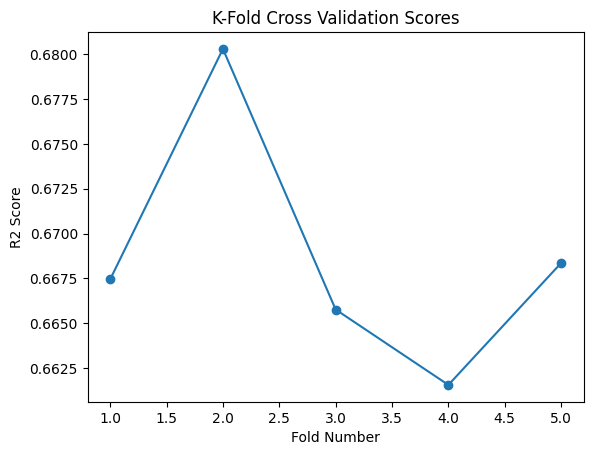

In [ ]:
plt.figure()

plt.plot(range(1,6), scores, marker='o')

plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("K-Fold Cross Validation Scores")

plt.show()

knn regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("Exam_Score_Prediction.csv")

# Preprocessing
df = df.drop("student_id", axis=1)
df = pd.get_dummies(df, drop_first=True)

# Features & target
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K (no printing inside loop)
best_k = 1
best_score = -1

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if score > best_score:
        best_score = score
        best_k = k

# Train final model with best K
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

# FINAL OUTPUT ONLY
print("Best K Value:", best_k)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best K Value: 13
R2 Score: 0.530195491600459
RMSE: 12.963320238786146


Bootstrap

In [ ]:
import numpy as np
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

n_iterations = 20
r2_list = []
rmse_list = []

for i in range(n_iterations):

    # Bootstrap sample (with replacement)
    X_sample, y_sample = resample(X, y, replace=True, random_state=i)

    # Train model
    model = LinearRegression()
    model.fit(X_sample, y_sample)

    # Predict on full dataset
    y_pred = model.predict(X)

    # Store metrics
    r2_list.append(r2_score(y, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y, y_pred)))

# Results
print("All R2 Scores:", r2_list)
print("Average R2:", np.mean(r2_list))

print("\nAll RMSE:", rmse_list)
print("Average RMSE:", np.mean(rmse_list))

All R2 Scores: [0.7319087548734564, 0.7318868746209657, 0.7320246720139244, 0.7317060929155719, 0.7320125311039529, 0.7318936656297295, 0.7318358662800257, 0.7319944907553897, 0.7319483746826905, 0.7319915419332208, 0.7318055209236318, 0.7319973560481647, 0.7319235412711378, 0.7319498045629177, 0.7319148352128533, 0.7319684313467937, 0.7320202914350307, 0.7318015792601491, 0.7318922287950931, 0.7318783073340454]
Average R2: 0.7319177380499372

All RMSE: [np.float64(9.790104628908955), np.float64(9.790504130188054), np.float64(9.787987880132011), np.float64(9.793804315090526), np.float64(9.788209605271017), np.float64(9.790380138085327), np.float64(9.791435404294266), np.float64(9.788539060491676), np.float64(9.789381187885315), np.float64(9.788592911215986), np.float64(9.791989386267314), np.float64(9.788486734878497), np.float64(9.789834641770037), np.float64(9.78935507787526), np.float64(9.78999360794598), np.float64(9.78901494126595), np.float64(9.788067881672108), np.float64(9.7920

LASSO REGRESSION

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lasso = Lasso(alpha=0.1)   # you can tune alpha
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("LASSO RESULTS")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

LASSO RESULTS
R2 Score: 0.7329102568857537
RMSE: 9.774313510549577


ridge regression


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Exam_Score_Prediction.csv")

# Preprocessing
df = df.drop("student_id", axis=1)
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge Regression model
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score (Accuracy):", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score (Accuracy): 0.7330105996526837
RMSE: 9.772477285418537


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)   # you can tune alpha
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("RIDGE RESULTS")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

RIDGE RESULTS
R2 Score: 0.7330105996526837
RMSE: 9.772477285418537


accuracy

In [ ]:
from sklearn.metrics import r2_score

# Lasso
print("Lasso Accuracy (R2 Score):", r2_score(y_test, y_pred_lasso))

# Ridge
print("Ridge Accuracy (R2 Score):", r2_score(y_test, y_pred_ridge))

Lasso Accuracy (R2 Score): 0.7329102568857537
Ridge Accuracy (R2 Score): 0.7330105996526837


decision tree

R2 Score: 0.585004136931296
RMSE: 12.18370972354806


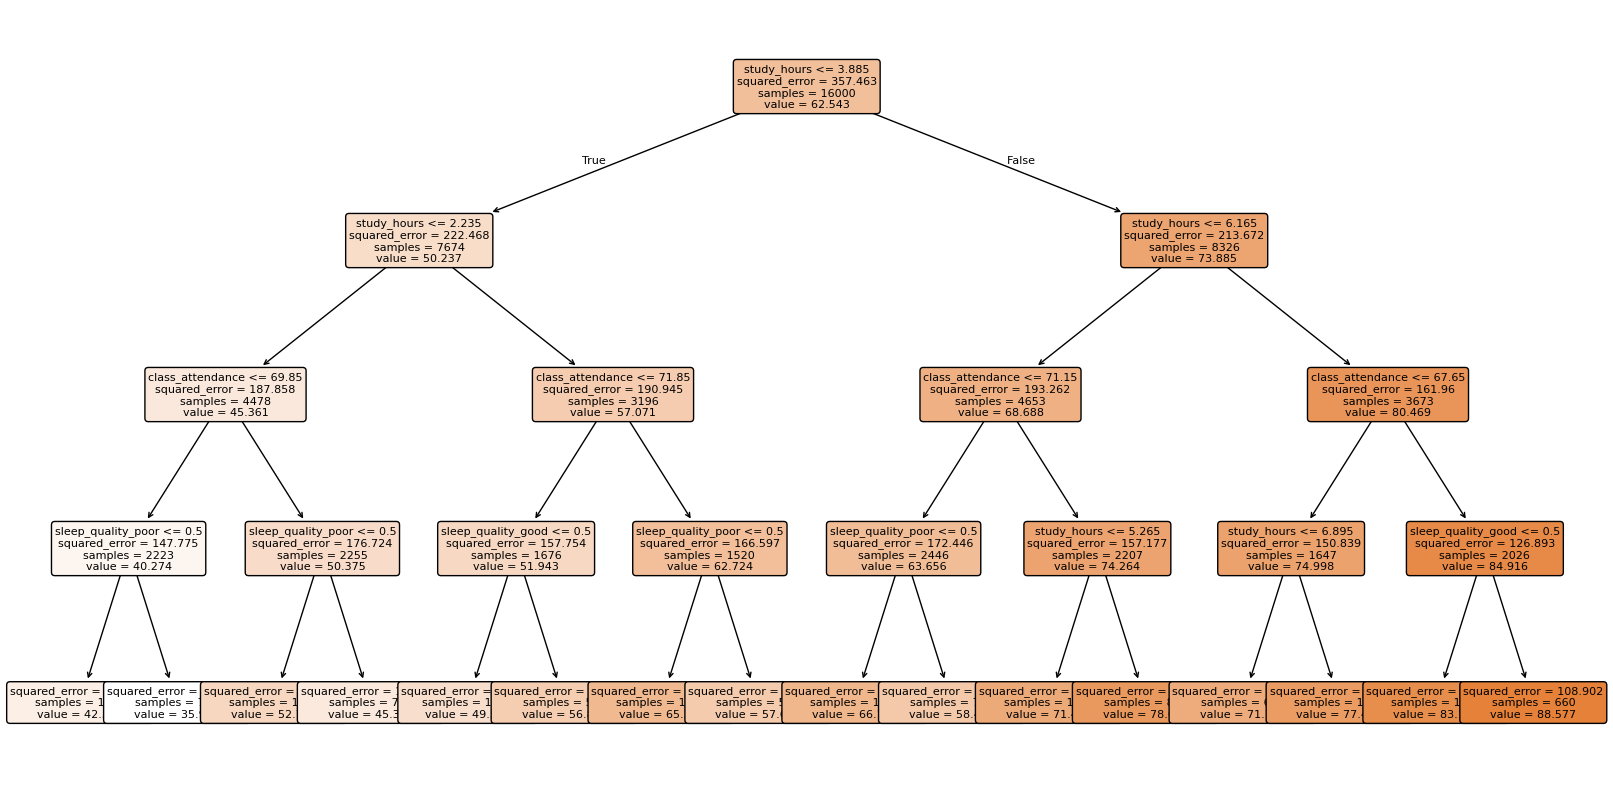

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("Exam_Score_Prediction.csv")

# Preprocessing
df = df.drop("student_id", axis=1)
df = pd.get_dummies(df, drop_first=True)

# Features & target
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Tree Plot
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.show()